# **Hands-On Tutorial : Bayesian Inference From Mock 21 cm Power Spectrum Data**
---

Venue : SKA India School on 21-cm Cosmology, TIFR Mumbai

Date : March 5, 2026

---

Contact : Anirban Chakraborty (Email : anirban.chakraborty096@gmail.com)

## **GOALS** :  

###The aim of this tutorial is two-fold:

####1.   To develop familiarity with a popular semi-numerical reionization code -- SCRIPT, and to learn how to use it to generate ionization maps and compute the corresponding 21 cm power spectra for different choices of model parameters.

####2.   To use SCRIPT in a Bayesian inference framework and constrain the global ionization  fraction from mock 21 cm power spectrum data
  
----

## **Please go through this tutorial by executing the cells sequentially, rather than running all the cells at once!**
---

#**Preliminary : Start a new Google Colab session**

If you have already executed this notebook once and the software installation or working folders are still present on the virtual machine, you must first clear them. To do this, follow these steps:


1.   Go to  ```Runtime``` in the top menu and select the ```Disconnect and delete runtime``` option.

2.   If the session does not reconnect automatically, click the ```Reconnect``` button in the top-right corner of the interface.







#**Part 0 : Download the mock dataset and install all the required packages**

Create a working directory

In [1]:
import os

# Define the base directory (default working location in Google Colab)
base_path = "/content"

# Create the path for a new working directory called "work"
work_path = os.path.join(base_path, "work")

# Create the directory if it does not already exist
os.makedirs(work_path, exist_ok=True)

# Change the current working directory to the newly created "work" folder
os.chdir(work_path)

# Print and confirm the current working directory
os.getcwd()


'/content/work'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Create a folder in the working directory to store all saved plots from the session

In [3]:
# Create a directory named "saved_figures" in the  working directory
os.makedirs("saved_figures", exist_ok=True)

Download the datafiles from the [Google Drive](https://drive.google.com/drive/folders/1UlX2ppcbQUyZlPpGbwxev3_dLrk3F-KD?usp=sharing) folder associated with this tutorial

In [4]:
# Download the simulation snapshot file from Google Drive
# -O specifies the output filename to save locally

!gdown 1cAFQ4Jk4Q4dq94yKKoG5DdIcDCJmQubM -O snap_file

# Download the mock 21cm power spectrum dataset from Google Drive
!gdown 10dxt0GW-TnD_3f7Aw7ajZI1r3PevMOAI -O mock_powspec_data.txt

Downloading...
From: https://drive.google.com/uc?id=1cAFQ4Jk4Q4dq94yKKoG5DdIcDCJmQubM
To: /content/work/snap_file
100% 58.7M/58.7M [00:00<00:00, 171MB/s]
Downloading...
From: https://drive.google.com/uc?id=10dxt0GW-TnD_3f7Aw7ajZI1r3PevMOAI
To: /content/work/mock_powspec_data.txt
100% 447/447 [00:00<00:00, 1.99MB/s]


Let us now import the required python libraries

In [5]:
# Modules used for interacting with the operating system and Python environment
import os, sys

# Add the current working directory to Python's module search path
sys.path.append(os.getcwd())

# NumPy: library for numerical computations and array operations
import numpy as np

# Matplotlib: library for generating and displaying plot
import matplotlib.pyplot as plt
import matplotlib


In [6]:
# Define plotting style parameters

fontsize = 14     # Base font size used throughout the plots
axisLW = 2        # Line width for axes and plot lines
ticksize = 10     # Size (length) of major tick marks
dpiValue = 120    # Resolution of figures (dots per inch)

plt.rcParams.update({

    "font.size": fontsize,                 # Default font size for all text
    "font.family": "sans-serif",           # Use sans-serif font family

    "figure.figsize": [8, 6],             # Default figure size in inches (width, height)
    "figure.dpi": dpiValue,                # Resolution of the figure (dots per inch)
    "figure.titlesize": 1.5 * fontsize,    # Font size of the overall figure title

    "axes.titlesize": 1.5 * fontsize,     # Font size of axes titles
    "axes.labelsize": 1.25 * fontsize,      # Font size of x and y axis labels
    "axes.linewidth": axisLW + 0.1,        # Thickness of the axis frame/spines

    "xtick.labelsize": fontsize,           # Font size of x-axis tick labels
    "ytick.labelsize": fontsize,           # Font size of y-axis tick labels


    "xtick.major.width": axisLW,           # Width of major ticks on x-axis
    "ytick.major.width": axisLW,           # Width of major ticks on y-axis

    "xtick.major.size": ticksize,          # Length of major ticks on x-axis
    "ytick.major.size": ticksize,          # Length of major ticks on y-axis

    "xtick.minor.width": axisLW,           # Width of minor ticks on x-axis
    "ytick.minor.width": axisLW,           # Width of minor ticks on y-axis

    "xtick.minor.size": ticksize / 2,      # Length of minor ticks on x-axis
    "ytick.minor.size": ticksize / 2,      # Length of minor ticks on y-axis

    "legend.fontsize": fontsize + 2,       # Font size used in the legend
    "legend.loc": "best",                  # Automatically place legend in best location

    "lines.markersize": ticksize,          # Default marker size in plots
    "lines.linewidth": axisLW + 0.5,       # Default line width for plot lines
})

# **PROVIDED: A mock observation of the 21 cm Power Spectrum at z = 7**


The mock observational data used in this tutorial consist of measurements of the **dimensionless 21 cm power spectrum**, $\Delta^2_{21}(k)$, evaluated at a set of discrete wavenumbers $k$.

The data file provided to you contains the following columns:

- **$k$** : the comoving wavenumber in units of $h\,\mathrm{cMpc}^{-1}$.
- **$\Delta^2_{21}(k)$** : the measured (mock) 21 cm power spectrum amplitude in units of $\mathrm{mK}^2$.
- **$\sigma_{21}$**  :  the $1\,\sigma$ uncertainty on the power spectrum measurement in units of $\mathrm{mK}^2$.

Although this dataset represent a **mock observation**, the observational uncertainties are based on the expected **SKA-LOW sensitivity**. In particular, the errors were calculated using the code [21cmSense](https://github.com/rasg-affiliates/21cmSense), assuming an observational campaign with the **SKA-LOW AA\*** telescope array, observing for **6 hours per day over 10 days**, with a total **bandwidth of 8 MHz**.





Let us first look at the mock dataset.

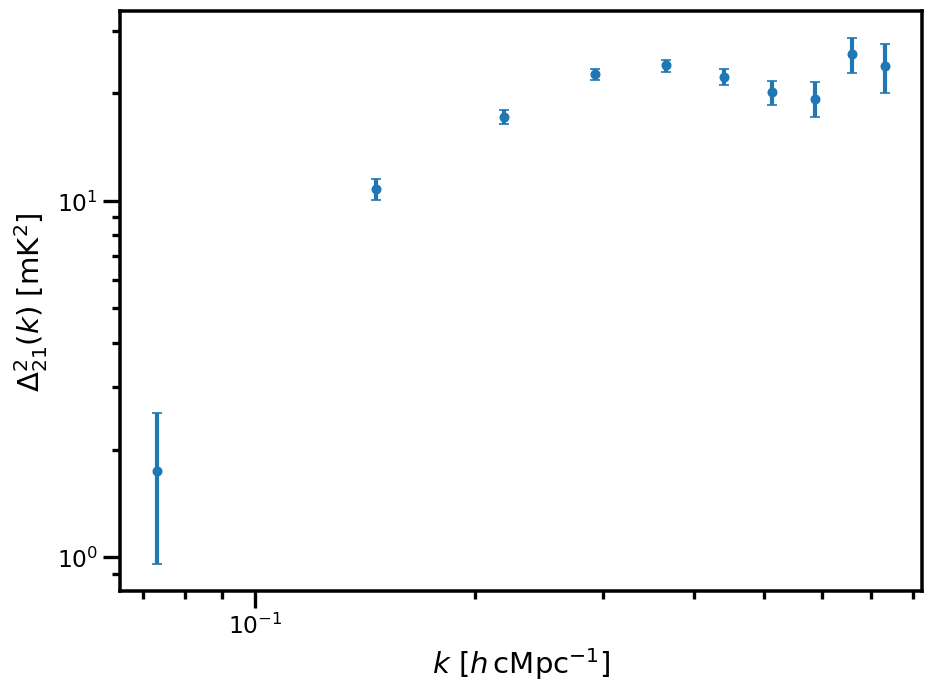

In [7]:
# Load the mock 21 cm power spectrum data
data = np.loadtxt('./mock_powspec_data.txt')

# k-bin centers in units of h/cMpc
kbins_data = data[:, 0]

# Width of the k-bins
deltak_hMpc = np.diff(kbins_data)[0]


# Observed (mock) 21 cm power spectrum values and their uncertainties
Delta_sq_21cm_obs = data[:, 1]
Delta_sq_21cm_error = data[:, 2]

# Plot the mock observational data with error bars
plt.errorbar(kbins_data,
             Delta_sq_21cm_obs,
             yerr=Delta_sq_21cm_error,
             fmt='.',
             capsize=3)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k ~ [h \, \mathrm{cMpc}^{-1}]$')
plt.ylabel(r'$\Delta^2_{21}(k) ~ [\mathrm{mK}^2]$')


# Construct the k-bin edges from bin centers
# (useful later when computing the power spectrum)
kedges_data = np.concatenate([[kbins_data[0] - deltak_hMpc/2],kbins_data + deltak_hMpc/2])  # units : h/cMpc


plt.tight_layout()
plt.savefig('./saved_figures/mockdata.pdf')

# **A Theoretical Model of Cosmic Reionization  (SCRIPT)**

**SCRIPT** stands for **S**emi Numerical **C**ode for **R**eion**I**zation with **P**ho**T**on Conservation. It was introduced to mitigate the issue of photon number non conservation associated with other standard semi-numerical codes based on Excursion Set (ES) methods.

For details, see [Choudhury & Paranjape (2018)](https://doi.org/10.1093/mnras/sty2551) and visit [SCRIPT repository](https://bitbucket.org/rctirthankar/script) for documentation of code  and examples .

The N-body simulation data for this tutorial was generated through the 2LPT code [MUSIC](https://www-n.oca.eu/ohahn/MUSIC/).

---

# Part 1: Install and Get Familiar with SCRIPT





We will first install **SCRIPT** from the [SCRIPT repository](https://bitbucket.org/rctirthankar/script).

In [8]:
# Change the current working directory back to the base path
os.chdir(base_path)

# Install SCRIPT and its dependencies

# Install the FFTW3 library (required by SCRIPT for fast Fourier transforms)
!apt-get install libfftw3-dev >/dev/null

# Clone the SCRIPT repository from Bitbucket
!git clone https://bitbucket.org/rctirthankar/script > /dev/null

Cloning into 'script'...
Receiving objects: 100% (584/584), 100.39 MiB | 16.01 MiB/s, done.
Resolving deltas: 100% (263/263), done.


The above step will create a folder named
```script``` in the base directory. We will need to go inside this folder and then, install the code

In [9]:
# Move into the SCRIPT directory
script_path = os.path.join(base_path, "script")
os.chdir(script_path)


# Install SCRIPT using pip from the current directory.
!pip install .
#This will setup various modules required to perform our tasks.

Processing /content/script
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for script: filename=script-1.0-cp312-cp312-linux_x86_64.whl size=267869 sha256=c7682790b9dca1ff1307d3cf65350ad2f29ebbd15ec9085579286aaac8df798e
  Stored in directory: /tmp/pip-ephem-wheel-cache-1u9ulpqt/wheels/93/56/e3/9dede06009803bf8b48a032781ea9659fa76c868e71e1b4d3b
Successfully built script


Let us then return to our working directory

In [10]:
# Go back to the working directory
os.chdir(work_path)

If **SCRIPT**`was installed correctly, the next cell should execute without raising any errors.

In [11]:
# for using the SCRIPT package

import script

##(1A): Compute the field : $\zeta \, f_{\mathrm{coll}}(>M_{\mathrm{min}}$) at $z=7$ for $M_{\mathrm{min}}=10^8 M_\odot$ and $\zeta$ = 8




For the snapshot used in this tutorial, the **SCRIPT** simulation was run with the following specifications:
Boxsize = 128  $h^{-1}$ cMpc
No. of DM particles = $128^3$



Now we will read the binary simulation file generated from **SCRIPT** at $z = 7$.

This file contains infomation about the dark matter particles ($x_i,v_i,M_i$) and box parameters.

For this, we will use the `default_simulation_data` class inside the `script` module.

*Note: You still need to supply the cosmological parameters*




In [12]:
# Name of the simulation snapshot file (generated by MUSIC)
gadget_snap = 'snap_file'

# Directory where SCRIPT will save the generated density and velocity fields
outpath = './script_saved_files'

# Use 1e-3 if the length unit for the MUSIC run was kpc/h, and 1.0 if it was in Mpc/h
scaledist = 1e-3

# Read the binary simulation snapshot and initialize the default simulation data structure
# Cosmological parameters must be supplied here
default_simulation_data = script.default_simulation_data(
    gadget_snap,
    outpath,
    sigma_8=0.829,
    ns=0.961,
    omega_b=0.0482,
    scaledist=scaledist
)

Once the dark matter particle data is retrieved, the next step is to construct the density, velocity, and halo collapsed fraction fields on a uniform grid, which are required for computing the ionization fields. This can be done using `matter_fields` class inside the `script` module.
  

**Question:**

At what spatial resolution ( $\Delta x$ = ?? ) should we generate the ionization maps for inference from the given mock data?  

The number of grids is then simply calculated as : $n_{\mathrm{grid}}$ = $L_{\mathrm{box}}/\Delta x$





In [13]:
# Number of grid cells per dimension used to smooth and discretize the density field
ngrid =   32   ## Your answer goes here


# Generate (or read) the gridded fields such as density and velocity
matter_fields = script.matter_fields(default_simulation_data, ngrid, outpath, overwrite_files=False)

# If overwrite_files=True, SCRIPT will recompute and overwrite the saved gridded fields.
# If overwrite_files=False, existing gridded fields will be read from disk (if available).

Next, we compute the quantity $ \zeta \, f_{\mathrm{coll}}$ in each cell of the simulation box.

Here $f_{\mathrm{coll}}$ is the fraction of mass inside collapsed objects with mass above a threshold of $M_{\mathrm{min}}$, and $\zeta$ is the effective ionizing efficiency of these sources.

We use the `get_zeta_fcoll` function in the `matter_fields` class.



In [14]:
# Minimum mass of halo (in solar masses) capable of producing ionizing radiation
log10Mmin = 8.0

# Effective ionizing efficiency of haloes
zeta = 8


## Calculate zeta times collapse fraction for each cell
zeta_times_fcoll_arr = matter_fields.get_zeta_fcoll(zeta,log10Mmin)

print ( 'zeta times fcoll = ' +  '{:.2f}'.format(np.mean(zeta_times_fcoll_arr * (1 + matter_fields.densitycontr_arr))) ) # predicted ionized fraction

zeta times fcoll = 0.59


## (1B) : Generating ionization maps and plotting power spectra for $\zeta=8$ and $M_{\mathrm{min}}=10^8 M_\odot$

For constructing the ionization map, we need to compute the ionized fraction field. This can be done using the `ionization_map` class. By default, the code uses the **Photon Conservation (PC)** method to generate the ionization maps.



In [15]:
# Initialize the ionization_map class using the previously computed matter fields
# This object will be used to generate the ionization maps of the simulation box
ionization_map = script.ionization_map(matter_fields)

Once the object is set up, we can compute the **ionized hydrogen fraction (HII)** in each cell of the simulation box using the `get_qi` function of the `ionization_map` class.

In [16]:
# Compute the ionized hydrogen fraction (q_i) in each cell of the simulation box
qi_arr = ionization_map.get_qi(zeta_times_fcoll_arr)

Let us do a quick check to verify whether the computed ionized hydrogen fraction matches the predicted ionized fraction (a salient feature of SCRIPT)

In [17]:
qi_mean = np.mean(qi_arr * (1 + matter_fields.densitycontr_arr))
print ( 'mass averaged ionized fraction = ' + '{:.2f}'.format(qi_mean) ) # mass averaged ionized fraction of Hydrogen
print ( 'mean zeta times fcoll = ' +  '{:.2f}'.format(np.mean(zeta_times_fcoll_arr * (1 + matter_fields.densitycontr_arr))) ) # predicted ionized fraction

mass averaged ionized fraction = 0.59
mean zeta times fcoll = 0.59


Once the ionized fraction in each cell is calculated, we construct the **HI overdensity field**, which is given by $\Delta_{\mathrm{HI}}= (1 - x_{\mathrm{HII}}) \,\cdot\, (1 + \delta)$, where $x_{\mathrm{HII}}$ is the ionized hydrogen fraction in each cell and $\delta$ is the density contrast in the same cell.  

Using this HI overdensity field, we can then compute the **HI power spectrum**.


In [18]:
# Initialize the power spectrum calculation
# Prepare the FFT plans and internal variables

matter_fields.initialize_powspec()


# Neutral hydrogen fraction field (HI fraction)
x_HI_arr = (1 - qi_arr)

# HI density field:
Delta_HI_arr = (1 - qi_arr) * (1 + matter_fields.densitycontr_arr)

# Compute the binned 21 cm power spectrum
powspec_21cm_binned, kount = ionization_map.get_binned_powspec(
    Delta_HI_arr,
    k_edges=kedges_data,
    units='mK',
    convolve=True
)

# k_edges specifies the bin edges in k-space
# units='mK' converts the power spectrum to brightness temperature units
# convolve=True accounts for the finite cell size effectss (CIC window function)

Let us plot the computed 21 cm power spectrum and some two-dimmensional slices from the simulation box

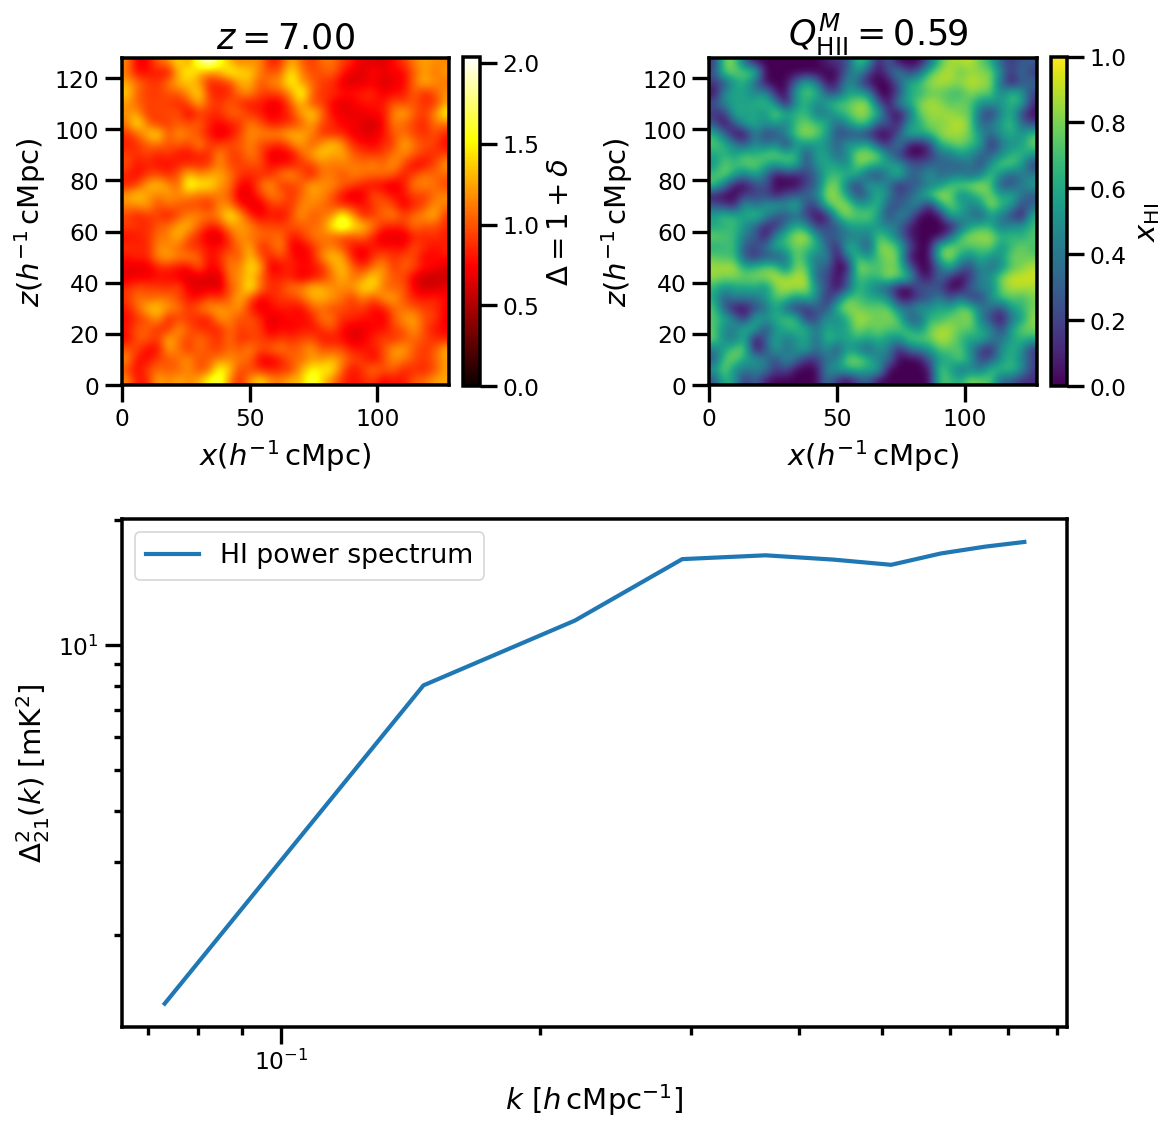

In [19]:
# Create a square figure to hold multiple panels
fig = plt.figure(figsize=(10,10))

# Top-left panel: matter density field slice
ax_den = fig.add_subplot(221)

# Top-right panel: neutral hydrogen (HI) field slice
ax_HI = fig.add_subplot(222)

# --------------------------------------------------

# Simulation box size (in h^-1 cMpc)
box = default_simulation_data.box

# Position of the slice through the box (in units of box size)
centre = 0.5

# Number of grid cells along each dimension
ngrid = matter_fields.ngrid

# Grid spacing
dx = box / ngrid

# Index corresponding to the chosen slice location
ygrid = int(ngrid * centre)


# Plot the matter overdensity field

# Set color scale limits
vmin = 0
vmax = None

# Display the density field slice
im_den = ax_den.imshow(
    1 + matter_fields.densitycontr_arr[:, ygrid, :].T,
    origin='lower',
    extent=[0, box, 0, box],
    interpolation='bicubic',
    cmap=plt.get_cmap('hot'),
    vmin=vmin,
    vmax=vmax
)

ax_den.set_xlabel(r'$x (h^{-1} \, \mathrm{cMpc})$')
ax_den.set_ylabel(r'$z (h^{-1} \, \mathrm{cMpc})$')
ax_den.set_title(r'$z = ' + '{:.2f}'.format(default_simulation_data.z) + '$')

# Add colorbar for the density field
cbar_den = fig.colorbar(im_den, ax=ax_den, fraction=0.046, pad=0.04)
cbar_den.set_label(r'$\Delta = 1 + \delta$')


# Plot the neutral hydrogen (HI) fraction field

# Set color scale limits for HI fraction
vmin = 0
vmax = 1

# Display HI fraction slice
im_HI = ax_HI.imshow(
    x_HI_arr[:, ygrid, :].T,
    origin='lower',
    extent=[0, box, 0, box],
    interpolation='bicubic',
    cmap=plt.get_cmap('viridis'),
    vmin=vmin,
    vmax=vmax
)


ax_HI.set_xlabel(r'$x (h^{-1} \, \mathrm{cMpc})$')
ax_HI.set_ylabel(r'$z (h^{-1} \, \mathrm{cMpc})$')
ax_HI.set_title(rf'$\ Q_{{\mathrm{{HII}}}}^{{M}} = {qi_mean:.2f}$')

# Add colorbar for HI fraction
cbar_HI = fig.colorbar(im_HI, ax=ax_HI, fraction=0.046, pad=0.04)
cbar_HI.set_label(r'$x_{\mathrm{HI}}$')


# Plot the HI power spectrum

# Bottom panel spanning the full width
ax_pk = fig.add_subplot(212)

# Plot the dimensionless HI power spectrum
ax_pk.plot(
    kbins_data,
    kbins_data**3 * powspec_21cm_binned / (2 * np.pi**2),
    label='HI power spectrum'
)

# Alternative: plot only bins with modes
# ax_pk.plot(kbins_data[kount > 0],
#            kbins_data[kount > 0]**3 * powspec_21cm_binned / (2 * np.pi**2),
#            label='HI power spectrum')


ax_pk.legend(loc='best')

ax_pk.set_xscale('log')
ax_pk.set_yscale('log')
ax_pk.set_xlabel(r'$k ~ [h \, \mathrm{cMpc}^{-1}]$')
ax_pk.set_ylabel(r'$\Delta^2_{21}(k) ~ [\mathrm{mK}^2]$')



fig.tight_layout()
plt.tight_layout()

plt.savefig(
    './saved_figures/SCRIPT_output_zeta' + str(zeta) +
    '_logMmin' + str(log10Mmin) + '.pdf'
)

# Display the figure
plt.show()

Let us now define a Python function that computes the **theoretical 21 cm power spectrum** from SCRIPT for a given set of parameters.

The function will take two parameters:

- $\log_{10}(M_{\mathrm{min}})$ — the minimum halo mass (in solar masses) capable of hosting ionizing sources.
- $\zeta$ — the ionizing efficiency parameter.

and return the **dimensionless 21 cm power spectrum** and the **mass-averaged ionized fraction**.

This will come handy as we go along

In [20]:
def SCRIPT_theorymodel(log10Mmin, zeta):
    """
    Compute the theoretical 21 cm power spectrum for a given set of model parameters.

    Parameters
    ----------
    log10Mmin : float
        Logarithm (base 10) of the minimum halo mass hosting ionizing sources.

    zeta : float
        Ionizing efficiency parameter controlling the production of ionizing photons.

    Returns
    -------
    Delta_sq_21cm : ndarray
        Dimensionless 21 cm power spectrum Δ²₍₂₁₎(k) in units of mK².

    QHII_mean : float
        Mass-averaged ionized fraction.
    """

    # zeta times collapsed fraction field for halos above Mmin
    zetafcoll_arr = matter_fields.get_zeta_fcoll(zeta, log10Mmin)   # shape = (ngrid, ngrid, ngrid)

    # Ionization field
    qi_arr = ionization_map.get_qi(zetafcoll_arr)          # shape = (ngrid, ngrid, ngrid)


    # Neutral hydrogen overdensity field
    Delta_HI_arr = (1 - qi_arr) * (1 + matter_fields.densitycontr_arr)

    # Mass-averaged ionized fraction
    QHII_mean = np.mean(qi_arr * (1 + matter_fields.densitycontr_arr))


    # Power spectrum calculation
    # Initialize power spectrum calculation
    matter_fields.initialize_powspec()

    # Compute the binned 21 cm power spectrum
    powspec_21cm, kount = ionization_map.get_binned_powspec(
        Delta_HI_arr,
        k_edges=kedges_data,
        units='mK',
        convolve=True
    )
    # Units: mK^2 h^{-3} cMpc^3


    # Convert to dimensionless power spectrum Δ²(k)
    Delta_sq_21cm = kbins_data**3 * powspec_21cm / (2 * np.pi**2)
    # Units: mK^{2}


    # Return the power spectrum and mean ionized fraction
    return Delta_sq_21cm, QHII_mean

## **(Home??) Exercise 1** :

### a. Generate ionization maps and 21 cm power spectra for $\log_{10} (M_{\mathrm{min}}/M_\odot)=[8.0, 8.5,9.0] $ with $\zeta$ = 8.

### b. Compare the power spectra and the mass-averaged ionized fraction for different values of $M_{\mathrm{min}}$.

### c. What do you see from a comparison of power spectrum?

In [21]:
##
## Your code goes here

##

## **(Home??) Exercise 2** :

### a. Generate ionization maps and 21 cm power spectra for $\log_{10} (M_{\mathrm{min}}/M_\odot)=8.0$ with $\zeta$ = [6,8,10].

### b. Compare the power spectra and the mass-averaged ionized fraction for different values of $\zeta$. What do you see from a comparison of power spectrum?

### c. What do you see from a comparison of power spectrum?

In [ ]:
##
## Your code goes here
##

# Part 2: Set Up the Likelihood Calculations

## Likelihood Function

To infer the global ionized fraction from the **mock observational data** under a **Bayesian formalism**, we must first define a **likelihood function**.


 Assuming that the measurement errors are Gaussian and uncorrelated between different $k$-bins, the likelihood function can be written as

$$
\mathcal{L}(\theta) \propto \exp\left[-\frac{1}{2}\chi^2(\theta)\right]
$$

where $\theta$ denotes the model parameters (e.g. $\log_{10} M_{\mathrm{min}}$ and $\zeta$), and

$$
\chi^2(\theta) =
\sum_i
\frac{\left[
\Delta^2_{21,\mathrm{model}}(k_i \mid \theta)
-
\Delta^2_{21,\mathrm{obs}}(k_i)
\right]^2}
{\sigma_i^2}.
$$

Here  

- $\Delta^2_{21,\mathrm{model}}(k_i \mid \theta)$ is the **model-predicted 21 cm power spectrum**,  
- $\Delta^2_{21,\mathrm{obs}}(k_i)$ is the **observed (mock) power spectrum**,  
- $\sigma_i$ is the **uncertainty** in the $k_i$ -th bin.






## **Exercise 3**:
## Write a Function to Compute the Log-Likelihood


---

**Note:** We already have a function, `SCRIPT_theorymodel`, that returns the model-predicted 21 cm power spectrum and the mass-averaged ionized fraction for a given set of parameters.

In [37]:
# Define your Log-likelihood function

def my_log_likelihood_func(log10Mmin, zeta):
    """
    Compute the log-likelihood for a given set of model parameters by
    comparing the model-predicted 21 cm power spectrum with the mock
    observational data.

    Parameters
    ----------
    log10Mmin : float
        Log10 of the minimum halo mass (in solar masses) capable of hosting
        star formation.

    zeta : float
        Effective ionizing efficiency of the ionizing sources.

    Returns
    -------
    logL : float
        Log-likelihood value assuming Gaussian and uncorrelated errors.

    derived_param_dict : dict
        Dictionary containing derived quantities from the model.
        In this tutorial, the dictionary should be created in the appropiate
        format with ONLY one key "QHII_mean" and the corresponding value being
        the mass-averaged ionized fraction.
        e.g., derived_param_dict = {"QHII_mean": <<var_name>> }

      """

    chi_square = 0

    # Compute the model prediction using the SCRIPT theory model
    Delta_sq_21cm_pred, QHII_mass_avg_pred = SCRIPT_theorymodel(log10Mmin, zeta)

    # Compute residuals between data and model
    diff = Delta_sq_21cm_obs - Delta_sq_21cm_pred

    # Observational uncertainties in each k-bin
    sigma = Delta_sq_21cm_error

    # Compute the chi-square statistic
    chi_square = np.sum((diff / sigma) ** 2)

    # Store derived parameters for later analysis

    derived_param_dict = {"QHII_mean": QHII_mass_avg_pred }

    # Return log-likelihood

    return -0.5 * chi_square, derived_param_dict



Let us check the value of the likelihood for $\log_{10} (M_{\rm min}/M_\odot) = 8$ and $\zeta = 8$

In [38]:
## check value of the likelihood for some parameter vector
print(my_log_likelihood_func(log10Mmin=8,zeta=8))

(np.float64(-123.33298052411224), {'QHII_mean': np.float32(0.5897047)})


# Part 3 : Run a Monte carlo Markov Chain analysis using **Cobaya**

For this tutorial, we will perform parameter inference using a **Monte Carlo Markov Chain (MCMC)**  sampler. The sampler explores the parameter space of the model parameters (e.g., $\log_{10}(M_{\mathrm{min}}/M_\odot)$ and $\zeta$), generating samples distributed according to the posterior probability. From these samples, we can estimate constraints on the model parameters and derived quantities such as the mean ionized fraction $Q_{\mathrm{HII}}$.



To carry out this analysis, we will use the publicly available package **Cobaya** (**CO**de for **BAY**esian **A**nalysis). It is a flexible framework for Bayesian parameter inference and statistical modelling, widely used in cosmology to sample posterior distributions using Monte Carlo methods. It allows users to efficiently explore parameter spaces using different samplers. The official documentation and source code can be found here:  https://cobaya.readthedocs.io/en/latest/


Let us first install the package

In [33]:
! pip install cobaya getdist

To run an MCMC analysis with **Cobaya**, we must define a Python informational dictionary (or YAML  file) that tells Cobaya how the inference problem is structured.


This dictionary is organized into several input blocks. The order of these blocks does not matter, but each serves a specific purpose. The main input blocks relevant for this tutorial are:

*   `likelihood`
    This block specifies the likelihood functions that will be evaluated during the sampling. Each likelihood can include additional options that control how the likelihood is computed.

     In our case, we pass a **custom external likelihood** (viz, the `my_log_likelihood_func`  function introduced earlier).


*   `params`
    This block defines the model parameters. For each parameter we can specify whether it is fixed or sampled, define its prior distribution, and provide useful metadata such as LaTeX labels for plotting.


*   `sampler`
    This block specifies the sampling algorithm that will be used to explore the parameter space (e.g., MCMC). It also contains options controlling the behavior of the sampler.



    Other input blocks such as `prior` and `theory` can also be included if needed, but they are **optional** and are not required for the simple setup used in this tutorial.

    **Note:**
    *The `prior` block is different from the priors specified within the `params` block. Priors defined inside `params` apply **independently to individual parameters** (e.g., uniform or Gaussian priors on a single parameter). In contrast, the `prior` block is used to define **external or joint priors** that may depend on **multiple parameters simultaneously** or cannot be expressed as separable priors on individual parameters. For example, it can be used to impose constraints such as relationships between parameters or multi-dimensional prior distributions.*

In addition, there are some **top-level options** (i.e., defined outside any block):

- `output`: Specifies the directory where the output files are written and/or the prefix for their names.

- `debug`: Controls the verbosity of the output. By default (`False` or undefined), it provides informative messages about initialization, progress, and results. If set to `True`, it produces very verbose output (a few lines per sample) useful for debugging.


## (3A) Create a **Cobaya** information dictionary for your analysis

In [39]:
# Cobaya info dict setup

# Name prefix for the MCMC chain files produced by COBAYA
fileroot = "mcmc_sphPS_z7p0"

# Directory where all MCMC chains and related output files will be stored
chainsdir = os.path.join(work_path, "chains_MCMC")

print("chains location :", chainsdir)


user_input_info = {

    "likelihood": {
                      "21cm_model": {
                                        "external": my_log_likelihood_func,
                                        "output_params": ["QHII_mean"]
                                    }
                  },

    "params": {
                      "log10Mmin": {
                                        "prior": {"min": 7.0, "max": 11.0},
                                        "proposal": 0.01,
                                        "ref": 8.5,
                                        "latex": r"\log_{10} M_{min}"
                                    },

                      "zeta":       {
                                        "prior": {"min": 1.0, "max": 100},
                                        "proposal": 0.01,
                                        "ref": 25.0,
                                        "latex": r"\zeta"
                                    },

                      "QHII_mean":  {
                                        "derived": True,
                                        "latex": r"Q^{M}_{HII}"
                                    }
             },

    "sampler": {
                      "mcmc": {
                                  "measure_speeds": True,
                                  "Rminus1_stop": 0.05,
                                  "max_tries": 10000000,
                                  "learn_every": 15,
                                  "learn_proposal_Rminus1_max": 10
                              }
    },

    "output": chainsdir + "/" + fileroot,
    #"debug": "debug_MCMC.txt"
}



chains location : /content/work/chains_MCMC


If an output chain directory with the same name already exists, please delete it; otherwise **Cobaya** will raise an error.

---

Simply uncomment the cell below and execute it.

In [40]:

import shutil
shutil.rmtree(chainsdir)
print(f"Removed directory: {chainsdir}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/work/chains_MCMC'

##(3B) We will now initiate the MCMC run.

The results of a **Cobaya** run consist of an updated **information dictionary** along with the output products generated by the chosen sampler.



In [41]:
# Launch the MCMC run with Cobaya
from cobaya.run import run
updated_info, sampler_outproducts = run(user_input_info, resume=True) # type: ignore

INFO:output:Output to be read-from/written-into folder '/content/work/chains_MCMC', with prefix 'mcmc_sphPS_z7p0'


[output] Output to be read-from/written-into folder '/content/work/chains_MCMC', with prefix 'mcmc_sphPS_z7p0'


INFO:21cm_model:Initialized external likelihood.


[21cm_model] Initialized external likelihood.


INFO:mcmc:Getting initial point... (this may take a few seconds)


...

[mcmc]  - Convergence of bounds: R-1 = 0.088161 after 705 accepted steps


INFO:mcmc:The run has converged!


[mcmc] The run has converged!


INFO:mcmc:Sampling complete after 705 accepted steps.


[mcmc] Sampling complete after 705 accepted steps.


# Part 4 : Visualising the MCMC chains and  Obtaining Parameter Constraints




Finally, we will analyze the MCMC chains generated in the previous step
and extract constraints on the EoR model parameters and the global ionized fraction at $z=7$.

To load the MCMC chains produced by **Cobaya** and visualize the posterior distributions, we will use the **GetDist** package.

For detailed documentation and usage examples, see the official GetDist documentation:  
https://getdist.readthedocs.io/en/latest/

A helpful reference showing the different types of plots that can be generated with GetDist is available in the **GetDist plot gallery**:  
https://getdist.readthedocs.io/en/latest/plot_gallery.html

In this section, we will perform the following tasks:

1. Load the MCMC chains after removing an initial **burn-in fraction**.
2. Visualize the marginalized **one- and two-dimensional posterior distributions** using triangle plots.
3. Estimate the **best-fit values and credible intervals** for the sampled parameters.
4. Interpret the inferred constraints on the **model parameters** and derived quantities, such as the **global ionized fraction**.

**IMPORTANT**

Unfortunately, if it happens that your MCMC analysis did not converge during the tutorial, you can download the chains for a converged MCMC run from the [Google Drive](https://drive.google.com/drive/folders/1UlX2ppcbQUyZlPpGbwxev3_dLrk3F-KD?usp=drive_link) folder to proceed forward.


## (4A) Inspecting the Overall Progress of the MCMC Run


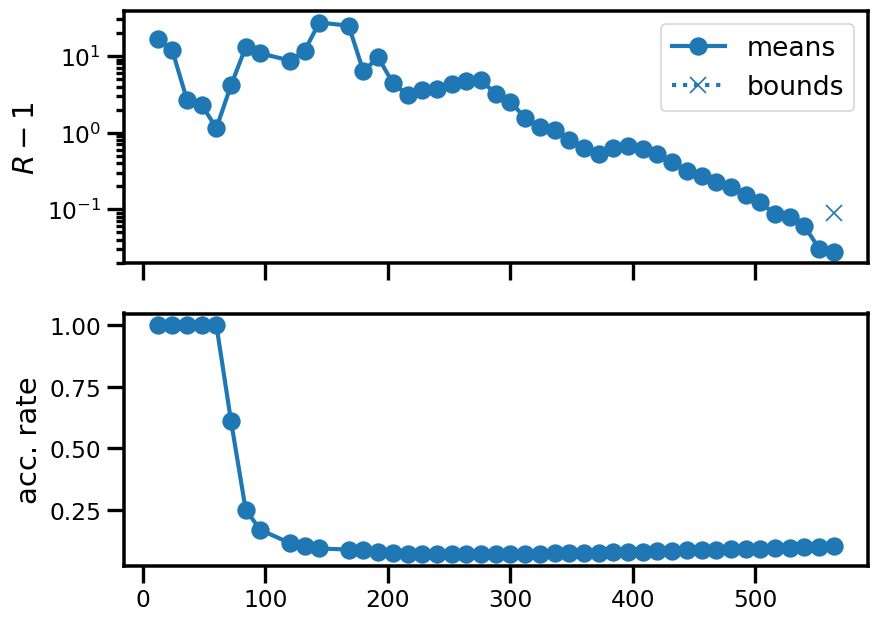

In [42]:
from cobaya.samplers.mcmc import plot_progress

plot_progress(chainsdir+'/'+fileroot)

plt.savefig('./saved_figures/MCMC_chain_progress_plot.pdf')


## (4B) Inspecting the Individual Chains of the MCMC Run

Before analyzing the posterior distributions, it is useful to examine the individual MCMC chains produced during the run. This helps diagnose potential issues such as lack of convergence, poor mixing, or long burn-in phases.

In this step we will visualize the **trace plots** of the sampled parameters and the corresponding **$\chi^2$ values** for each chain as a function of the sample number.

# Trace plots allow us to verify that:

- The chains have **moved away from their initial starting points** (burn-in phase).
- The chains **overlap and explore the same region of parameter space**, indicating good mixing.

- The $\chi^2$ values have stabilized, suggesting convergence.

Below we load the chains generated by **Cobaya**, extract the samples from each chain file, and plot the evolution of the sampled parameters and $\chi^2$ values.

[root] *WARNING* outlier fraction 0.12907801418439716 


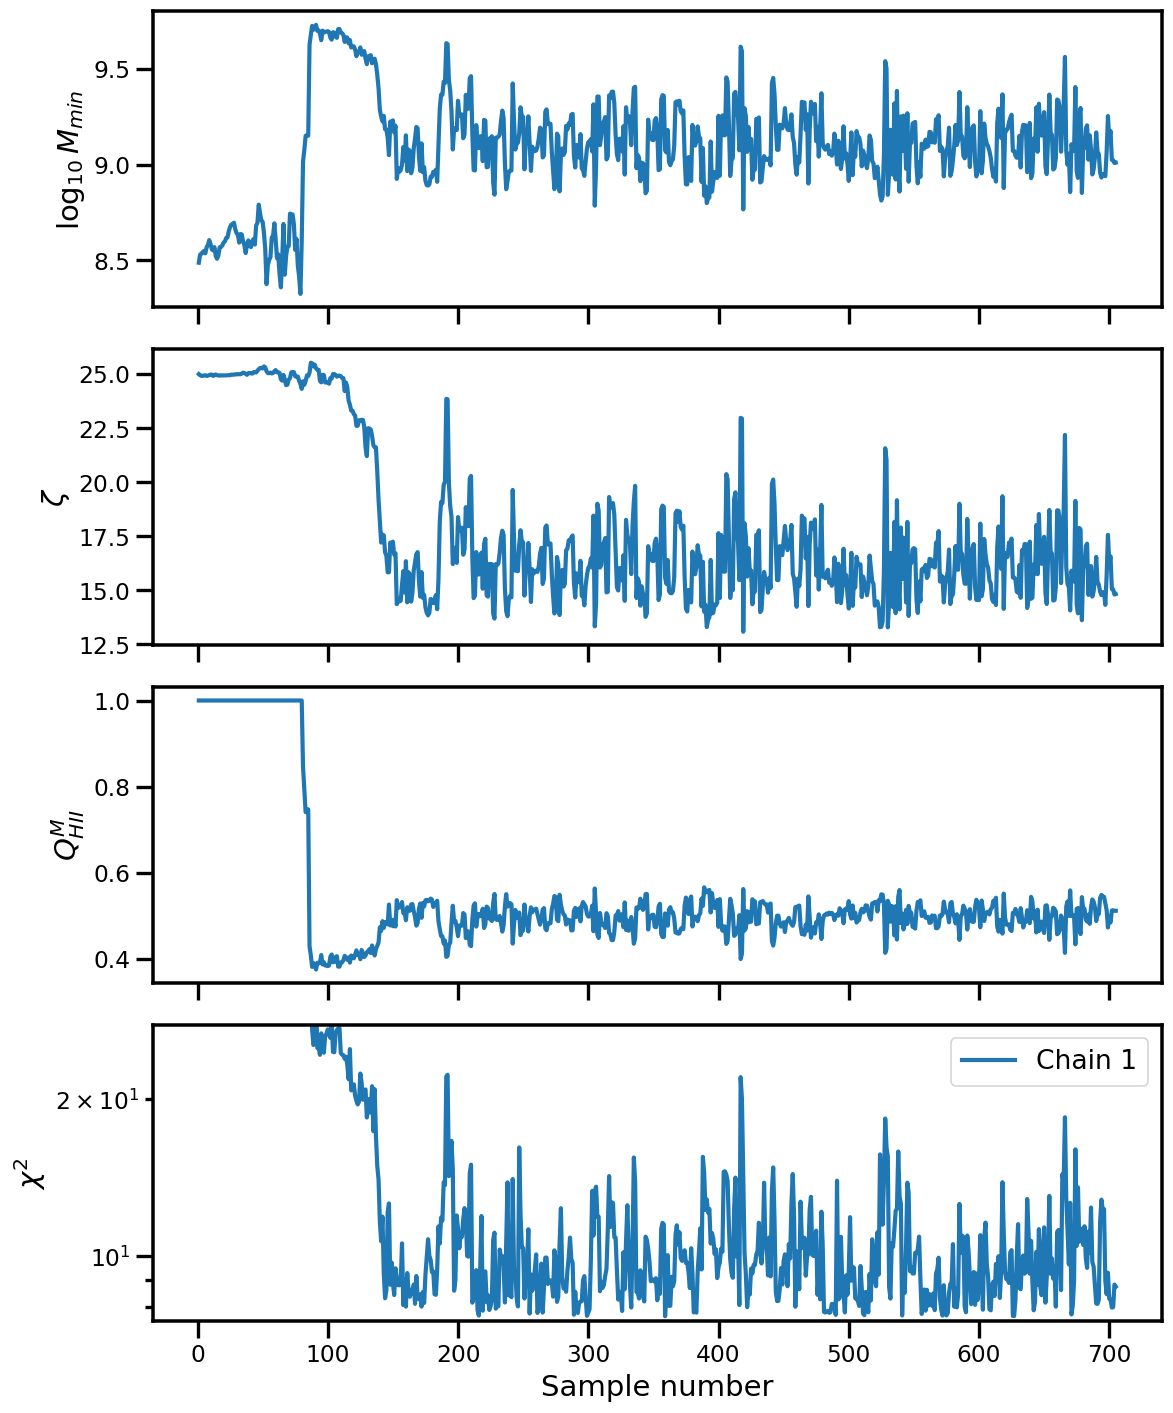

In [43]:
## Taken from SCRIPT Github version
## Works even when you have multiple root files

from getdist import loadMCSamples
from pathlib import Path

# Configuration: set these before running
chains_dir = Path(chainsdir)        # e.g. Path("chains/N64_L64.0")
samples = loadMCSamples(str(chains_dir / fileroot),settings={'ignore_rows':0.0})

# 1) Gather and sort all chain files like "fileroot.1.txt", "fileroot.2.txt",..
chain_paths = sorted(
    chains_dir.glob(f"{fileroot}.*.txt"),
    key=lambda p: int(p.stem.split('.')[-1])
)

# 2) Load each chain's samples into a list of arrays
chain_data_list = [np.loadtxt(p) for p in chain_paths]

# 3) Stack them for summary stats
all_data = np.vstack(chain_data_list)
n_samples, n_columns = all_data.shape

# 4) Determine how many subplots we need: (n_columns - 5)
#    where last one is chi2 and the rest are parameters
n_subplots = n_columns - 5

# 5) Extract chi2 column and its min
chi2_values = all_data[:, -1]
chi2_min = chi2_values.min()

# 6) Create figure with one row per parameter + one for chi2
fig, axes = plt.subplots(
    n_subplots, 1,
    figsize=(10, 3 * n_subplots),
    sharex=True
)

# 7) Plot progress of each chain
for chain_idx, data in enumerate(chain_data_list, start=1):
    x = np.arange(1, data.shape[0] + 1)

    # a) Plot each parameter trace
    for param_idx in range(n_subplots - 1):
        ax = axes[param_idx]
        y = data[:, param_idx + 2]
        ax.plot(x, y, label=f"Chain {chain_idx}")
        if chain_idx == 1:
            # label only on the first chain
            label = samples.getParamNames().labels()[param_idx]
            ax.set_ylabel(f"${label}$")
        # switch to symmetric-log if the dynamic range is huge
        if chain_idx > 13 and (y.max() / y.min()) > 1e2:
            ax.set_yscale("symlog")

    # b) Plot chi2 on the last axis
    axes[-1].plot(x, data[:, -1], label=f"Chain {chain_idx}")

# 8) Finalize chi2 subplot
axes[-1].set_ylabel(r"$\chi^2$")
axes[-1].set_yscale("log")
axes[-1].set_ylim(
    0.98 * chi2_min,
    max(1.05 * chi2_min, chi2_min + 20)
)
axes[-1].legend()

# 9) Labels & layout
axes[-1].set_xlabel("Sample number")
plt.tight_layout()
plt.savefig('./saved_figures/MCMC_chain_samples.pdf')

plt.show()



## (4C) Estimating the Best-Fit Parameters

After inspecting the chain behavior, we discard an initial **burn-in fraction** of the samples and use the remaining part of the chain for our analysis.

Using **GetDist**, we load the MCMC chain while ignoring the specified burn-in portion. We then identify the **best-fit point**, defined as the sample with the **minimum $\chi^2$ value** from the chain.


In [44]:
# fraction of initial samples to discard as burn-in
burn_in = 0.4

burned_samples = loadMCSamples( str(chains_dir / fileroot), settings={'ignore_rows': burn_in})

# Identify the best-fit sample (minimum chi-square)

# Extract chi-square values stored in the chain
chi2 = burned_samples.getParams().chi2

# Find the index of the minimum chi-square value
best_index = np.argmin(chi2)

# Extract the parameter values corresponding to this sample
bestfit = burned_samples.samples[best_index]

# Print the best-fit parameters
print("Best-fit parameters:")

for name, value in zip(burned_samples.getParamNames().names, bestfit):
    print(name.name, "=", value)

[root] *WARNING* outlier fraction 0.1182033096926714 
Best-fit parameters:
log10Mmin = 9.0736974
zeta = 15.588338
QHII_mean = 0.50547099
chi2 = 7.6816542
chi2__21cm_model = 7.6816542


##(4D) Marginalized Parameter Constraints

Next, we compute the **marginalized parameter statistics** from the MCMC chains.

The `getMargeStats()` function calculates the **one-dimensional marginalized constraints** for each parameter. These typically include:

- The **mean** value
- The **standard deviation**  
- The **credible intervals** (e.g., 68% and 95% confidence limits)

Printing these statistics provides a convenient summary of the inferred constraints on the model parameters from the MCMC analysis.

In [45]:
# Get the marginalized statistics for all sampled parameters
margestats = burned_samples.getMargeStats()
print(margestats)

Marginalized limits: 0.68; 0.95; 0.99

parameter          mean           sddev          lower1         upper1         limit1 lower2         upper2         limit2 lower3         upper3         limit3 
log10Mmin          9.0986187E+00  1.3741569E-01  8.9495070E+00  9.2255579E+00  two    8.8370182E+00  9.3800530E+00  two    8.7851146E+00  9.5395539E+00  two     \log_{10} M_{min}
zeta               1.5968503E+01  1.4657260E+00  1.4295573E+01  1.7073714E+01  two    1.3408135E+01  1.8960594E+01  two    1.2763754E+01  2.0659784E+01  two     \zeta
QHII_mean*         5.0124119E-01  2.6699543E-02  4.7538400E-01  5.2820115E-01  two    4.4881591E-01  5.5981147E-01  two    4.2587255E-01  5.7151445E-01  two     Q^{M}_{HII}
chi2*              9.7282142E+00  1.9034137E+00  7.6979963E+00  1.0314225E+01  two    7.3271995E+00  1.4021911E+01  two    7.0459025E+00  1.6046872E+01  two     \chi^2
chi2__21cm_model*  9.7282142E+00  1.9034137E+00  7.6979963E+00  1.0314225E+01  two    7.3271995E+00  1.4021911E+0

It is possible to also export a similar summary table with the parameter constraints included in LaTeX format directly.

In [46]:
print(burned_samples.getTable(limit=1).tableTex())

\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\log_{10} M_{min}$} & $9.10^{+0.13}_{-0.15}      $\\

{\boldmath$\zeta          $} & $16.0^{+1.1}_{-1.7}        $\\

$Q^{M}_{HII}               $ & $0.501\pm 0.027            $\\

$\chi^2                    $ & $9.7\pm 1.9                $\\

$\chi^2_\mathrm{21cm\ model}$ & $9.7\pm 1.9                $\\
\hline
\end{tabular}



## (4E) Plotting the Posterior Distributions

We now visualize the posterior distributions of the sampled parameters using the **GetDist** plotting utilities. In particular, we generate a **triangle plot**, which shows:

- The **1D marginalized posterior distributions** along the diagonal.
- The **2D joint posterior contours** between parameter pairs.

The plot further includes the **68% limits** mentioned for each parameter.

[root] *WARNING* outlier fraction 0.1182033096926714 


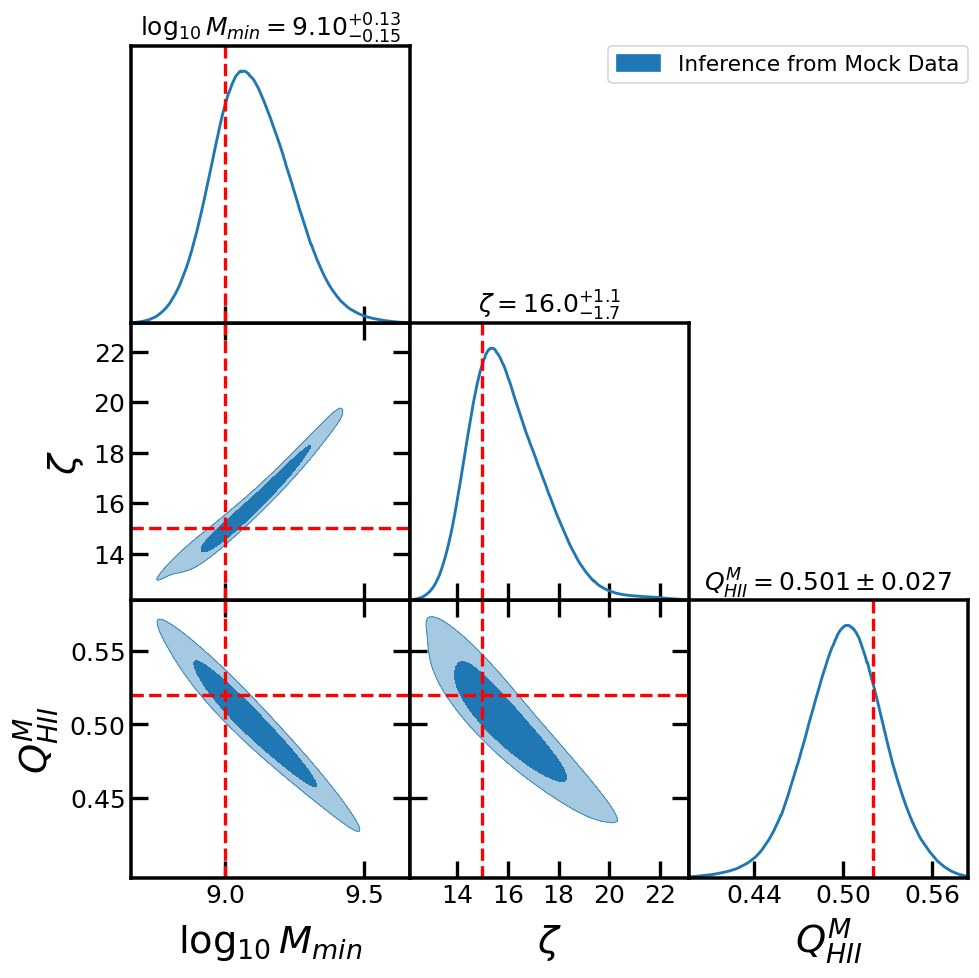

In [49]:
# Import the GetDist plotting utilities
from getdist import plots


# Settings used when analysing the chains
analysis_settings = {
    'ignore_rows': burn_in,          # Fraction of the chain to discard as burn-in
    'contours': [0.68, 0.95],        # Credible intervals to plot
    "smooth_scale_1D": -1,           # Automatic smoothing for 1D distributions
    "smooth_scale_2D": -1            # Automatic smoothing for 2D contours
}


# Create the GetDist plotter object and specify where the chains are stored
g = plots.get_subplot_plotter(
    chain_dir=chains_dir,
    analysis_settings=analysis_settings
)

# Disable caching so that the chains are reloaded each time
g.sample_analyser.use_cache = False


#############  Plot style settings #############
g.settings.alpha_factor_contour_lines = 0.8   # Transparency factor for contour lines
g.settings.axes_fontsize = 16                 # Font size for axis tick labels
g.settings.axes_labelsize = 24                # Font size for axis labels
g.settings.axis_marker_lw = 2                 # Line width of the vertical marker lines
g.settings.axis_marker_color = 'r'            # Color of the marker lines
g.settings.colorbar_axes_fontsize = 21        # Font size for colorbars
g.settings.fontsize = 16                      # General font size used in the plot
g.settings.legend_fontsize = 14               # Font size for legend text
g.settings.linewidth = 2                      # Line width for contour boundaries
g.settings.fig_width_inch = 9                 # Width of the final figure in inches
g.settings.num_plot_contours = 2              # Number of contour levels to plot (must match contour list)
g.settings.solid_colors = ['tab:blue']        # Color used for the filled contours

# List containing the chain root name
roots = [fileroot]


# Parameters to include in the triangle plot
params = ['log10Mmin', 'zeta', 'QHII_mean']

# Optional: include chi^2 if desired
# params = ['log10Mmin', 'zeta', 'QHII_mean', 'chi2']


# Truth values used in the mock data
marker_dict = {
    'log10Mmin': 9.0,
    'zeta': 15,
    'QHII_mean': .52
}


# Generate the triangle plot showing 1D and 2D marginalized posteriors
g.triangle_plot(
    roots,
    params,
    filled=True,
    markers=marker_dict,
    title_limit=1,
    legend_labels=[r'Inference from Mock Data']
)


# Save the generated plot
g.export('./saved_figures/MCMC_triangle_plot.pdf')

## (4F) Visualizing A Few Random Posterior Samples

To understand how well the inferred model parameters reproduce the data, we draw a number of **random samples from the posterior distribution** obtained from the MCMC chains.

For each such sampled parameter pair $(\log_{10} M_{\min}, \zeta)$, we compute the corresponding 21 cm power spectrum using the `SCRIPT_theorymodel`. These model predictions are then plotted together with the mock observational data.

This visualization helps illustrate:
- the **spread of models allowed by the posterior**, and  
- how the **best–fit model** compares to the data.

In the plot, grey curves correspond to random posterior samples. The black curve shows the best–fit model, while blue points with error bars represent the mock observational data.

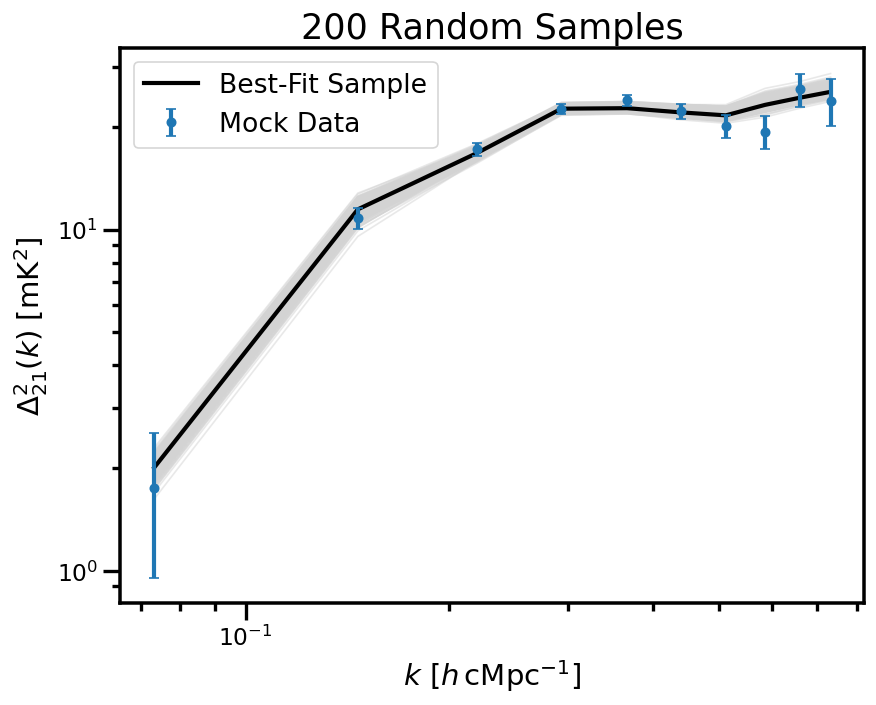

In [48]:
# Extract the posterior samples from the MCMC chains
posterior = burned_samples.samples   # shape: (Nsamples, Nparams)

# Separate the sampled parameter arrays
log10Mmin_arr = posterior[:, 0]
zeta_arr      = posterior[:, 1]

# Number of random posterior samples to visualize
nrand = 200

# Set a random number generator seed for reproducibility
rng = np.random.default_rng(seed=12345)

# Randomly select indices from the posterior samples
indices = np.random.choice(
    np.arange(len(posterior)),
    size=nrand,
    replace=False,
)

# Plot model predictions for the random posterior samples


for i in indices:
    # Retrieve sampled parameters
    log10Mmin = log10Mmin_arr[i]
    zeta      = zeta_arr[i]

    # Compute the theoretical 21cm power spectrum
    Delta_sq_21cm_model, QHII_mass_mean = SCRIPT_theorymodel(log10Mmin, zeta)

    # Plot the model prediction
    plt.plot(kbins_data, Delta_sq_21cm_model, c='lightgrey', alpha=0.5, lw=1)


# Plot the best–fit model

Delta_sq_21cm_bestmodel, QHII_mass_mean_bestmodel = SCRIPT_theorymodel(bestfit[0], bestfit[1])

plt.plot(kbins_data,
         Delta_sq_21cm_bestmodel,
         c='k',
         label='Best-Fit Sample')


# ---------------------------------------------------
# Plot the mock observational data
# ---------------------------------------------------

plt.errorbar(
    kbins_data,
    Delta_sq_21cm_obs,
    yerr=Delta_sq_21cm_error,
    fmt='.',
    capsize=3,
    label='Mock Data'
)


# ---------------------------------------------------
# Plot formatting
# ---------------------------------------------------

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$k ~ [h \, \mathrm{cMpc}^{-1}]$')
plt.ylabel(r'$\Delta^2_{21}(k) ~ [\mathrm{mK}^2]$')

plt.title(f"{nrand} Random Samples")

plt.legend()

# Save the figure
plt.savefig('./saved_figures/MCMC_random_samples.pdf')